## Prediction of Wine type using Deep Learning


Deep learning is commonly used to analyze large datasets but to understand its core concepts it’s helpful to start with smaller, more manageable datasets. One such dataset is the Wine Quality dataset which includes information about the chemical properties of wines and their quality ratings.

In this project, we will use deep learning techniques to predict the quality of wine based on its chemical properties. We will start by loading the dataset, performing exploratory data analysis, preprocessing the data, and then building and evaluating a deep learning model.

The dataset consists of 12 variables. Here are a few of them:

* **Fixed Acidity:** This refers to the non-volatile acids in the wine, which contribute to the wine's tartness.
* **Volatile Acidity:** This refers to acetic acid content which can contribute to a vinegar-like taste in wine.
* **Citric Acid:** Citric acid is one of the fixed acids in wine.
* **Residual Sugar:** This is the sugar that remains after fermentation stops.
* **Chlorides:** Chlorides can contribute to saltiness in wine.
* **Free Sulfur Dioxide:** This is the sulfur dioxide that is added to wine.
* **Total Sulfur Dioxide:** This is the sum of bound and free sulfur dioxide.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras 
import tensorflow as tf

## 2. Loading and Preprocessing Data

In [16]:
# Load datasets with semicolon delimiter
red = pd.read_csv("redwinequality.csv", sep=';')
white = pd.read_csv("whitewinequality.csv", sep=';')

In [ ]:
# wines = pd.concat([red, white], ignore_index=True)
# wines dataframe will be created in the "Fix Dataset" section with proper type column


,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
...,...
6492,6.2;0.21;0.29;1.6;0.039;24;92;0.99114;3.27;0.5...
6493,6.6;0.32;0.36;8;0.047;57;168;0.9949;3.15;0.46;...
6494,6.5;0.24;0.19;1.2;0.041;30;111;0.99254;2.99;0....
6495,5.5;0.29;0.3;1.1;0.022;20;110;0.98869;3.34;0.3...


## Fix Dataset


In [20]:
# Add type column to datasets before concatenation
red['type'] = 1  # Red wine
white['type'] = 0  # White wine

# Recreate wines dataframe with type column
wines = pd.concat([red, white], ignore_index=True)

# Check for missing values
print("Missing values:\n", wines.isnull().sum())
print("\nDataset shape:", wines.shape)
print("Dataset info:")
print(wines.info())

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Dataset shape: (6497, 13)
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density             

In [21]:
wines

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0


## 3. Plotting Distribution of Alcohol  

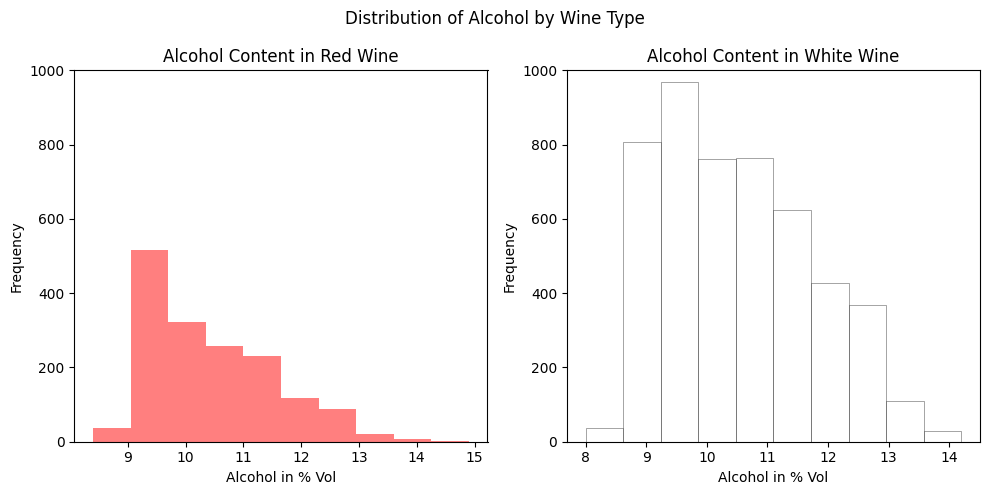

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

## 4. Splitting Data into Training and Testing Sets


In [22]:
X = wines.drop('type', axis=1)
y = wines['type']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  


## 5. Creating Neural Network Model

In [23]:
import tensorflow as tf

model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



c:\Users\PANDIT JI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6. Training the Model

In [24]:
model.fit(X_train, y_train, epochs=10, batch_size=1, verbose=1)

Epoch 1/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.8648 - loss: 1.0144
Epoch 2/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9450 - loss: 0.1630
Epoch 3/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9519 - loss: 0.1359
Epoch 4/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9589 - loss: 0.1169
Epoch 5/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9665 - loss: 0.1000
Epoch 6/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9690 - loss: 0.0907
Epoch 7/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9707 - loss: 0.0946
Epoch 8/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9716 - loss: 0.0866
Epoch 9/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9717 - loss: 0.0834
Epoch 10/10
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9797 - loss: 0.0724


## 7. Making Predictions


In [25]:
y_pred = model.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)

for prediction in y_pred_labels[:12]:
    wines_type = 'Red' if prediction == 1 else 'White'
    print(f'Predicted wine type: {wines_type}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted wine type: White
Predicted wine type: White
Predicted wine type: White
Predicted wine type: White
Predicted wine type: White
Predicted wine type: Red
Predicted wine type: White
Predicted wine type: White
Predicted wine type: Red
Predicted wine type: White
Predicted wine type: White
Predicted wine type: White


## save The model

In [ ]:
import joblib
import pickle
# joblib.dump(model, 'wine_prediction_model.pkl')

['wine_prediction_model.pkl']